# Una vida en el tiempo: consumo, ahorro y demografía

Un hogar con horizonte finito percibe un ingreso en forma de joroba, ahorra ante
el riesgo de ingreso y desacumula activos hacia el final de la vida. Resolvemos el
problema del ciclo de vida, analizamos la distribución de riqueza de la cohorte
por edad, y ponderamos las cohortes con un perfil demográfico (con y sin
mortalidad) para ver cómo el envejecimiento de la población remodela el capital
agregado. Todo con `puremacro.vfi`.

## El método en ecuaciones

Un hogar vive las edades $j = 0, 1, \dots, J-1$ (aquí $J = 40$). A diferencia del
problema de Aiyagari con horizonte infinito, esto **no** es un punto fijo: con un
valor terminal conocido se resuelve por *inducción hacia atrás* — exactamente $J$
aplicaciones del operador de Bellman de un paso, desde la última edad hasta la
primera. En la edad $j$, con activos $a$ y productividad idiosincrática $z$,
$$ V_j(a,z) = \max_{a' \ge 0}\; u(c) + \beta\, s_j\, \mathbb{E}\!\left[V_{j+1}(a',z') \mid z\right],
\qquad c = \kappa_j\, e^{z} + (1+r)\,a - a', $$
con utilidad CRRA $u(c) = (c^{1-\gamma}-1)/(1-\gamma)$ ($\gamma = 2$ aquí) y la
**condición terminal** $V_{J} \equiv 0$ — el hogar no valora nada después de la
última edad, de modo que no deja **ningún legado** y desacumula sus activos. El
ingreso es el producto de una *joroba determinista* $\kappa_j = \exp(0.1\,j - 0.0025\,j^2)$
y un riesgo AR(1) $e^{z}$; la tasa $r$ es fija (equilibrio parcial) y el
endeudamiento queda excluido por $a' \ge 0$. El factor $s_j \in (0,1]$ es la
probabilidad condicional de sobrevivir a la edad $j$, por lo que el descuento
*efectivo* de una edad a la siguiente es $\beta\, s_j$.

Una cohorte nace en la edad $0$ sin (casi) activos y envejece de forma
determinista: $\mu_{j+1} = \Pi^{\!\top}_z\, T_{j}\,\mu_j$, donde $T_j$ es la
política de ahorro de la edad $j$ y $\Pi_z$ la transición de la productividad.
Para convertir estas cohortes en una *sección transversal* ponderamos la edad $j$
por su **masa poblacional** $\ell_j$, con $\ell_0 = 1$ y
$\ell_{j+1} = \ell_j\, s_j / (1+n)$ (luego normalizada para sumar uno). Sin
mortalidad ($s_j \equiv 1$) ni crecimiento poblacional ($n = 0$), cada cohorte
tiene el mismo peso $1/J$; la mortalidad hace que los mayores sean menos
numerosos, por lo que sus (elevadas) tenencias de activos pesan menos en el
capital agregado $K = \sum_j \ell_j\, \mathbb{E}_j[a]$.

**Intuición.** Esta es la lógica del ingreso permanente / ciclo de vida. Un hogar
joven *sabe* que su ingreso crecerá hacia el máximo de mediana edad de $\kappa_j$,
por lo que querría endeudarse contra ese ingreso futuro para suavizar el consumo
— y solo se lo impide $a' \ge 0$, razón por la cual los jóvenes mantienen activos
cercanos a cero. A lo largo de la vida laboral, el ahorro frente a la caída de los ingresos tardíos y el
autoaseguramiento frente al choque AR(1) construyen un colchón de riqueza que
**alcanza su máximo cerca del final de la vida laboral**; con un valor terminal
nulo y sin motivo de legado, el hogar entonces *desacumula*, gastando el colchón
antes de la última edad. La ponderación por mortalidad importa para la sección
transversal porque los ricos en activos se concentran entre los mayores —
precisamente las cohortes que un perfil de supervivencia decreciente adelgaza.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi import life_cycle_profile, stationary_age_weights

## 1. El perfil del ciclo de vida
`life_cycle_profile` resuelve un problema de consumo-ahorro con 40 períodos de
vida (ganancias deterministas en forma de joroba × riesgo AR(1), sin
endeudamiento, sin legados) y devuelve los activos medios y el consumo medio por
edad, junto con la distribución de cohorte indexada por edad.

In [2]:
lc = life_cycle_profile(horizon=40, n_z=5, n_a=120, a_max=40.0)
assets_by_age = lc["assets_by_age"]
cons_by_age = lc["consumption_by_age"]
dist = lc["life_cycle_dist"]                               # (J, n_a, n_z)
J = assets_by_age.shape[0]
age = np.arange(J)
print(f"peak mean assets {assets_by_age.max():.2f} at age {assets_by_age.argmax()}")
assert assets_by_age.max() > assets_by_age[0]             # assets build up...
assert assets_by_age[-1] < assets_by_age.max()           # ...then draw down
assert np.all(cons_by_age > 0)

peak mean assets 8.53 at age 29


**Lee el resultado.** Los activos medios parten esencialmente de cero — los
recién nacidos entran sin nada y, bloqueados por la restricción de no
endeudamiento, no pueden adelantar las ganancias que esperan más tarde. Luego
ascienden de forma sostenida y alcanzan su máximo en el interior (la edad del
máximo que se imprime queda muy por debajo de la última edad $J-1 = 39$), la
joroba del ciclo de vida de manual: es ahorro frente a la caída de los ingresos tardíos más un colchón
precautorio frente al choque AR(1). Tras el máximo, el perfil se invierte — con
$V_J \equiv 0$ y sin legado, el hogar gasta óptimamente su riqueza hacia el final
de la vida, aunque no del todo hasta cero dada la combinación de supervivencia e
ingreso. El consumo se mantiene estrictamente positivo en todo momento y es
visiblemente más *suave* que la joroba de ingreso que lo impulsa: ese suavizado
es precisamente lo que compra la política de ahorro.

### Figura principal — la joroba
Los activos se acumulan durante la vida laboral y se desacumulan hacia el final;
el consumo es mucho más suave que la joroba de ingreso subyacente.

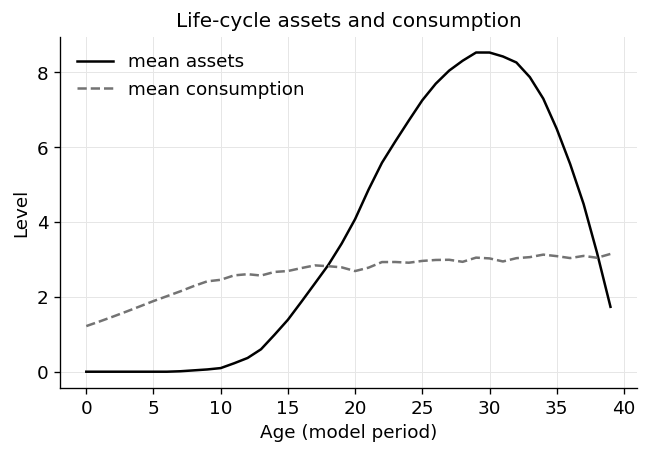

In [3]:
cols = _nbstyle.palette(2)
fig, ax = plt.subplots()
ax.plot(age, assets_by_age, color=cols[0], label="mean assets")
ax.plot(age, cons_by_age, color=cols[1], linestyle="--", label="mean consumption")
ax.set_xlabel("Age (model period)"); ax.set_ylabel("Level")
ax.set_title("Life-cycle assets and consumption"); ax.legend()
plt.show()

### Figura complementaria — la distribución de riqueza de la cohorte por edad
Cada columna es la distribución de riqueza de una edad (marginal sobre el
ingreso); la masa se expande hacia activos más elevados durante la vida laboral
y luego se contrae.

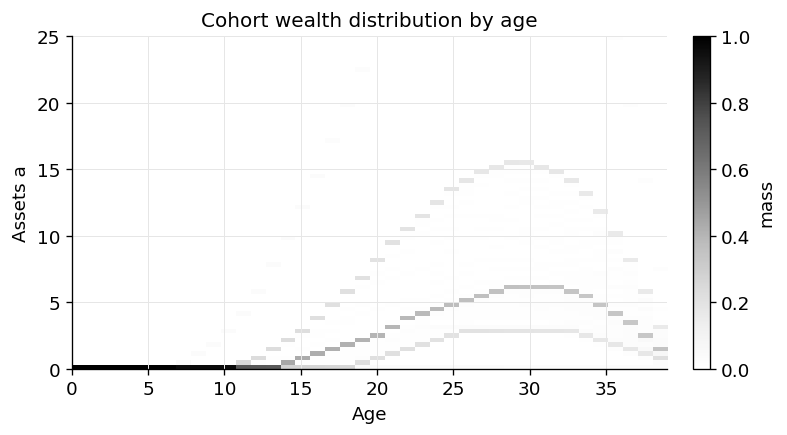

In [4]:
dist_a = dist.sum(axis=2)                                 # (J, n_a) marginal over z
a_grid = np.linspace(0.0, 40.0, dist_a.shape[1])
fig, ax = plt.subplots(figsize=(7.0, 3.6))
im = ax.imshow(dist_a.T, origin="lower", aspect="auto", cmap="Greys",
               extent=[0, J - 1, a_grid[0], a_grid[-1]])
ax.set_ylim(0, 25)
ax.set_xlabel("Age"); ax.set_ylabel("Assets a")
ax.set_title("Cohort wealth distribution by age")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="mass")
plt.show()

## 2. Demografía: quién está vivo y cuánto capital posee
Sin mortalidad, cada cohorte tiene masa igual (`1/J`). Al agregar un perfil de
supervivencia decreciente, los individuos mayores son menos numerosos — por lo
que sus tenencias de activos (elevadas) reciben menos peso en el agregado. El
capital agregado per cápita = Σ_edad peso × activos medios.

aggregate capital per capita: uniform 3.58, with mortality 2.80


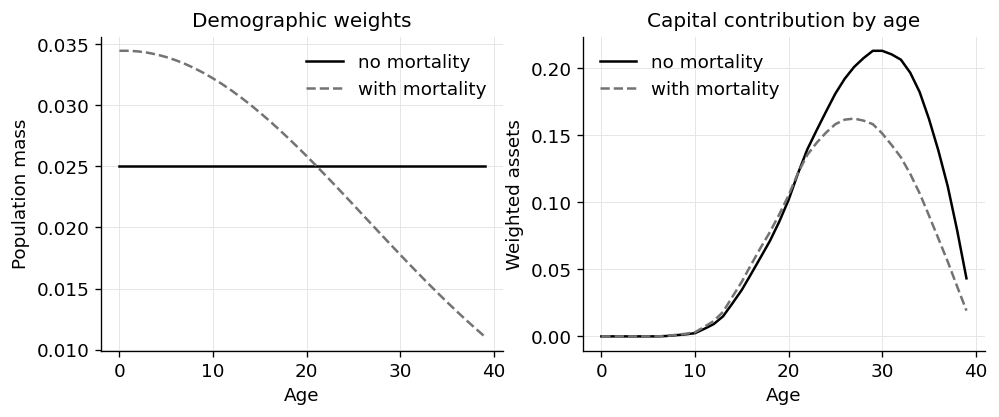

In [5]:
surv = np.clip(1.0 - 0.0015 * age, 0.85, 1.0)   # gentle decline; oldest cohort ~1/3 the youngest
w_uniform = stationary_age_weights(J)                     # no mortality → 1/J
w_mortality = stationary_age_weights(J, survival=surv)
K_uniform = float(np.sum(w_uniform * assets_by_age))
K_mortality = float(np.sum(w_mortality * assets_by_age))
print(f"aggregate capital per capita: uniform {K_uniform:.2f}, "
      f"with mortality {K_mortality:.2f}")
assert np.isclose(w_uniform.sum(), 1.0) and np.isclose(w_mortality.sum(), 1.0)
assert K_mortality < K_uniform                            # fewer asset-rich elderly

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.4))
a1.plot(age, w_uniform, color=cols[0], label="no mortality")
a1.plot(age, w_mortality, color=cols[1], linestyle="--", label="with mortality")
a1.set_xlabel("Age"); a1.set_ylabel("Population mass"); a1.set_title("Demographic weights")
a1.legend()
a2.plot(age, w_uniform * assets_by_age, color=cols[0], label="no mortality")
a2.plot(age, w_mortality * assets_by_age, color=cols[1], linestyle="--", label="with mortality")
a2.set_xlabel("Age"); a2.set_ylabel("Weighted assets"); a2.set_title("Capital contribution by age")
a2.legend()
plt.show()

## Tu turno — ¿sobrevive la joroba a un factor de descuento distinto?

El caso base resolvió un hogar con $\beta = 0.96$. La paciencia es la palanca
central del ahorro: un hogar más paciente valora más el futuro, por lo que
acumula un colchón *más alto*; uno impaciente ahorra menos. Volver a resolver el
problema del ciclo de vida es barato (son solo $J$ pasos de Bellman hacia atrás,
sin bucle de equilibrio), así que cambia `beta_you` abajo y observa cómo se mueve
el máximo — mientras la *forma* sigue siendo una joroba.

El assert verifica un **hecho estructural robusto**, no una magnitud frágil: para
cualquier $\beta$ admisible, el máximo de los activos medios cae estrictamente en
el interior (después de la edad 0, antes de la última edad), porque la restricción
de no endeudamiento fija a los jóvenes cerca de cero y el valor terminal nulo
fuerza la desacumulación al final.

In [6]:
# ← Change this discount factor (patience). Keep it strictly in (0, 1).
beta_you = 0.98
lc_you = life_cycle_profile(horizon=40, n_z=5, n_a=120, a_max=40.0, beta=beta_you)
assets_you = lc_you["assets_by_age"]
peak_age_you = int(assets_you.argmax())
print(f"beta={beta_you}: peak mean assets {assets_you.max():.2f} at age {peak_age_you} "
      f"(baseline beta=0.96 → {assets_by_age.max():.2f} at age {assets_by_age.argmax()})")
# Hump-shaped: the peak is interior (not the first or the last age) for any valid beta.
assert 0 < peak_age_you < J - 1, peak_age_you
assert assets_you[0] < assets_you.max() and assets_you[-1] < assets_you.max()
# More patient → at least as much peak wealth as the (less patient) 0.96 baseline.
assert (beta_you < 0.96) or (assets_you.max() >= assets_by_age.max() - 1e-9)

beta=0.98: peak mean assets 11.33 at age 29 (baseline beta=0.96 → 8.53 at age 29)


**Ejercicios.** (1) Fija `beta_you = 0.92` (impaciente): el máximo se encoge y se
desplaza ligeramente más tarde, pero sigue siendo interior — la joroba es
estructural, no un caso límite. (2) Sube a `beta_you = 0.99` (muy paciente) y
compara la riqueza máxima con el caso base; el hogar sobreahorra pero igual
desacumula para la última edad. (3) *Avanzado:* incrementa la pendiente del perfil
`surv` de arriba (p. ej. `0.0030 * age`, aún recortado a `(0, 1]`), recalcula
`w_mortality` y el capital agregado, y confirma que `K_mortality` cae aún más a
medida que se adelgaza a los mayores ricos en activos. (Para que la mortalidad
actúe *dentro* de la resolución — el descuento efectivo $\beta s_j$ — construye un
`FiniteHorizonProblem` directamente con su argumento `survival=`.)

**¿Qué tan completo es esto?** `life_cycle_profile` maneja la pila de horizonte
finito (`FiniteHorizonProblem` → `life_cycle_distribution` → `age_profile`) y
`stationary_age_weights` incorpora la demografía; `puremacro.vfi` cierra el círculo
con el **equilibrio general OLG con trabajo endógeno** (`olg_stationary_equilibrium`).
La misma maquinaria de resolución → distribución → vaciado de mercado impulsa los
demás cuadernos de muestra: la desigualdad de riqueza **Aiyagari / Huggett** de
horizonte infinito (NB01), el riesgo agregado y las trayectorias de transición de
**Krusell-Smith** (NB02), la entrada y salida de empresas de **Hopenhayn** (NB04), y
las carteras de **dos activos** con EGM y preferencias de Epstein-Zin (NB05).